#### Non Neuronal cells sourced from the human brain atlas. https://data.humancellatlas.org/hca-bio-networks/nervous-system/atlases/brain-v1-0

In [ ]:
#!pip install scarf
#!pip install cmocean
#!pip install numpy (possible need)

In [8]:
import scarf
import h5py

In [9]:
with h5py.File("non-neuronal cells.h5ad", "r") as f:
    print("=== Top-level keys ===")
    print(list(f.keys()))
    
    print("\n=== obs keys ===")
    print(list(f["obs"].keys()))
    
    print("\n=== var keys ===")
    print(list(f["var"].keys()))
    
    print("\n=== X structure ===")
    print(f["X"])
    if hasattr(f["X"], "keys"):
        print(list(f["X"].keys()))  # sparse matrix has indptr/indices/data
## just use this to be able to inspect the anndata file to then figure out how to map for the ZARR file

=== Top-level keys ===
['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']

=== obs keys ===
['CellID', 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'Region', 'assay', 'assay_ontology_term_id', 'cell_cycle_score', 'cell_type', 'cell_type_ontology_term_id', 'cluster_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'dissection', 'donor_id', 'fraction_mitochondrial', 'fraction_unspliced', 'is_primary_data', 'observation_joinid', 'roi', 'sample_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'subcluster_id', 'supercluster_term', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'total_UMIs', 'total_genes']

=== var keys ===
['Biotype', 'Chromosome', 'End', 'Gene', 'Start', '_index', 'feature_biotype', 'feature_is_filtered', 'feature_length', 'feature_name', 'feature_reference', 'feature_type']

=== X structure ===
<HDF5 group "/X" (3 member

In [10]:
scarf.__version__

'0.32.3'

In [12]:
# read the .h5ad data. If using other formats and need help converting, go to https://scarf.readthedocs.io/en/latest/vignettes/download_conversion.html
##### Only need to run THIS CMD initially to process the data
reader = scarf.H5adReader(
    h5ad_fn="non-neuronal cells.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)
# now write it to the .Zarr format that it wants to be in

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='non-neuronal_cells.zarr',
    chunk_size=(2000,1000)
)
writer.dump()



INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [13]:
ds = scarf.DataStore(
    'non-neuronal_cells.zarr', # same loco as where you saved the zarr
    nthreads=4,
    min_features_per_cell = 10 # only genes in more than 10 cells will be kept    
)
# reason it is safe to use a scalar factor of 1k even though we have cells with less reads is bc we filter them out in next step

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

#### 2) Time to do Cell Filtering

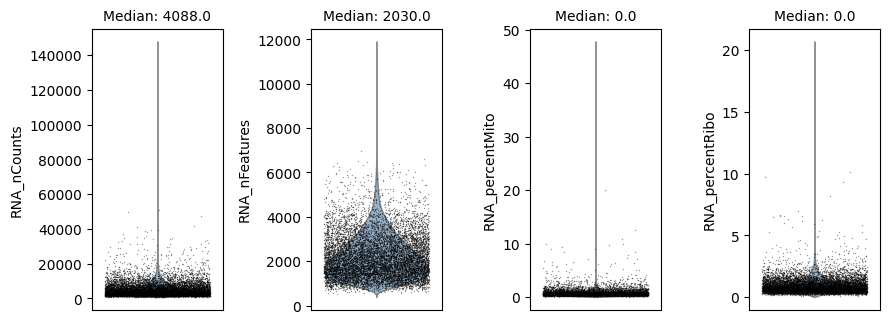

In [17]:
ds.plot_cells_dists()

In [18]:
# filtering out cells with more than 16000 counts, and cells with less than 1000 RNA_nCOUNTs
# filtering out cells with more than 4000 nFeatures, and cells with les than 500
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[16000, 4000],
    lows=[1000, 500]
)


INFO: 22755 cells flagged for filtering out using attribute RNA_nCounts
INFO: 46253 cells flagged for filtering out using attribute RNA_nFeatures


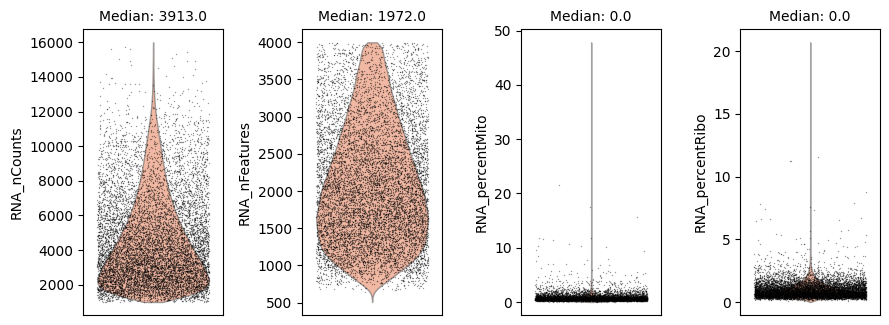

In [19]:
ds.plot_cells_dists(cell_key='I', color='coral') # now viewing our qc filtered data

In [20]:
ds.cells.head()

,I,ids,names,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,X_UMAP1,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X362_3:TCAGTGAGTATTGACC,10X362_3:TCAGTGAGTATTGACC,11170.0,3082.0,0.402865,0.331244,7.570669,1.252836,1.936434,-1.956834,0.001513,0.000445,0.828378,False,{98R6UpEqS,11234.0,3100.0
1,True,10X362_5:TCCGTGTGTGAAAGTT,10X362_5:TCCGTGTGTGAAAGTT,6492.0,2287.0,0.400493,0.215650,8.753119,0.428098,6.749318,17.554855,0.002145,0.000153,0.848476,False,@Emos2s5K+,6527.0,2303.0
2,True,10X362_5:CACGGGTAGAGCAGAA,10X362_5:CACGGGTAGAGCAGAA,6991.0,2712.0,0.386211,0.700901,9.805358,1.317603,6.266892,17.820768,0.001280,0.000000,0.801024,False,ba|aw+>z=F,7031.0,2733.0
3,False,10X362_5:GATTCTTGTATGTCAC,10X362_5:GATTCTTGTATGTCAC,21934.0,4731.0,0.496945,0.351053,12.621747,-0.648498,24.283781,10.955823,0.001995,0.000000,0.851632,False,r$+8sBgKyG,22060.0,4771.0
4,True,10X362_6:AGGACTTGTATCCTTT,10X362_6:AGGACTTGTATCCTTT,12858.0,3214.0,0.303313,0.287759,10.310822,1.272111,6.356893,17.940919,0.001936,0.000000,0.848084,False,sw*$Gke{CL,12915.0,3241.0


In [21]:
ds ## now we have sorted down to 839027 cells

DataStore has 839027 (888263) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'X_UMAP1', 'X_UMAP2', 'X_tSNE1', 
            'X_tSNE2', 'cell_cycle_score', 'fraction_mitochondrial', 'fraction_unspliced', 'is_primary_data', 
            'observation_joinid', 'total_UMIs', 'total_genes'
   RNA assay has 37161 (58232) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_is_filtered', 
            'nCells'

#### 3) Feature Selection



In [22]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,feature_is_filtered,nCells
0,True,ENSG00000000003,TSPAN6,857828,False,30435
1,True,ENSG00000000005,TNMD,887772,False,491
2,True,ENSG00000000419,DPM1,756665,False,131598
3,True,ENSG00000000457,SCYL3,789449,False,98814
4,True,ENSG00000000460,FIRRM,804009,False,84254


In [23]:
ds.RNA.sf ## this is our scaling factor when we normalize data
#ds.RNA.sf = some int n if we wanted to change it

1000

In [ ]:
## now identifying HVGs inside of the dataset using mark_hvgs

INFO: Calculating summary statistics
INFO: Using cached feature stats for cell_key I
INFO: Using existing corrected dispersion values
INFO: Calculating HVGs
INFO: 2000 genes marked as HVGs


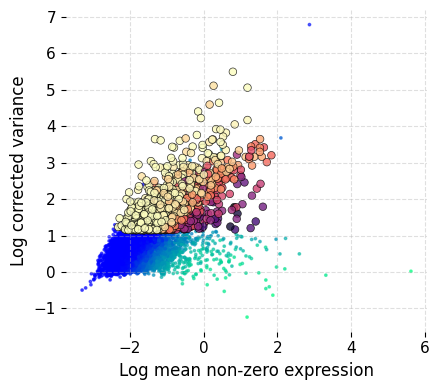

In [26]:
ds.mark_hvgs(
    min_cells=20, # genes found in at least 20 of the cells
    top_n=2000, # means the top 500 highest variable genes, when on mac mini do top 2k
    min_mean=-3,
    max_mean=2,
    max_var=6
) 

In [27]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells,stats_I_avg,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_normed_tot,stats_I_nz_mean,stats_I_sigmas
0,True,ENSG00000000003,TSPAN6,False,857828,False,30435,0.006930,1.189234,25162.0,6155.939561,0.244652,0.002523
1,True,ENSG00000000005,TNMD,False,887772,False,491,0.000104,1.646893,382.0,92.009526,0.240863,0.000038
2,True,ENSG00000000419,DPM1,False,756665,False,131598,0.033647,1.121441,112681.0,29887.117426,0.265237,0.012570
3,True,ENSG00000000457,SCYL3,False,789449,False,98814,0.024532,1.260930,83676.0,21790.540964,0.260416,0.009274
4,True,ENSG00000000460,FIRRM,False,804009,False,84254,0.026306,1.563383,74525.0,23366.225783,0.313535,0.012733


In [28]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=30, ## dims is the amount of PCA dimensions, on Mac mini move this up to 30
    n_centroids=100 
)

Normalizing with feature subset:   0%|                                                                        …

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.81%


#### 5) Now embedding and clustering

In [29]:
ds.run_umap(
    n_epochs=250, #could move to 500
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs
	completed  25  /  250 epochs
	completed  50  /  250 epochs
	completed  75  /  250 epochs
	completed  100  /  250 epochs
	completed  125  /  250 epochs
	completed  150  /  250 epochs
	completed  175  /  250 epochs
	completed  200  /  250 epochs
	completed  225  /  250 epochs


In [30]:
ds.cells.head() # now we can see where the umaps are stored

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,X_UMAP1,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X362_3:TCAGTGAGTATTGACC,10X362_3:TCAGTGAGTATTGACC,11.847340,-2.960084,11170.0,3082.0,0.402865,0.331244,7.570669,1.252836,1.936434,-1.956834,0.001513,0.000445,0.828378,False,{98R6UpEqS,11234.0,3100.0
1,True,10X362_5:TCCGTGTGTGAAAGTT,10X362_5:TCCGTGTGTGAAAGTT,16.992125,-8.226686,6492.0,2287.0,0.400493,0.215650,8.753119,0.428098,6.749318,17.554855,0.002145,0.000153,0.848476,False,@Emos2s5K+,6527.0,2303.0
2,True,10X362_5:CACGGGTAGAGCAGAA,10X362_5:CACGGGTAGAGCAGAA,21.838242,-1.690997,6991.0,2712.0,0.386211,0.700901,9.805358,1.317603,6.266892,17.820768,0.001280,0.000000,0.801024,False,ba|aw+>z=F,7031.0,2733.0
3,False,10X362_5:GATTCTTGTATGTCAC,10X362_5:GATTCTTGTATGTCAC,NaN,NaN,21934.0,4731.0,0.496945,0.351053,12.621747,-0.648498,24.283781,10.955823,0.001995,0.000000,0.851632,False,r$+8sBgKyG,22060.0,4771.0
4,True,10X362_6:AGGACTTGTATCCTTT,10X362_6:AGGACTTGTATCCTTT,0.867150,15.464523,12858.0,3214.0,0.303313,0.287759,10.310822,1.272111,6.356893,17.940919,0.001936,0.000000,0.848084,False,sw*$Gke{CL,12915.0,3241.0


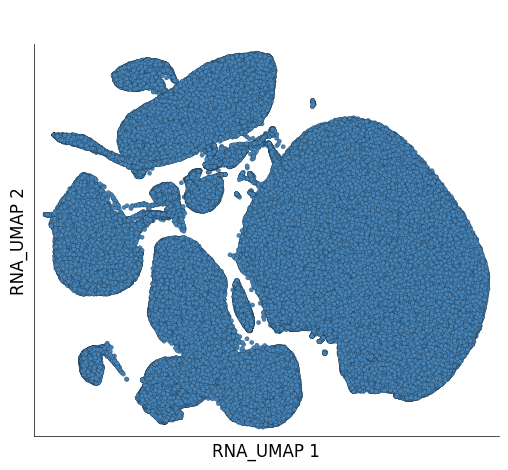

In [31]:
ds.plot_layout(layout_key='RNA_UMAP')

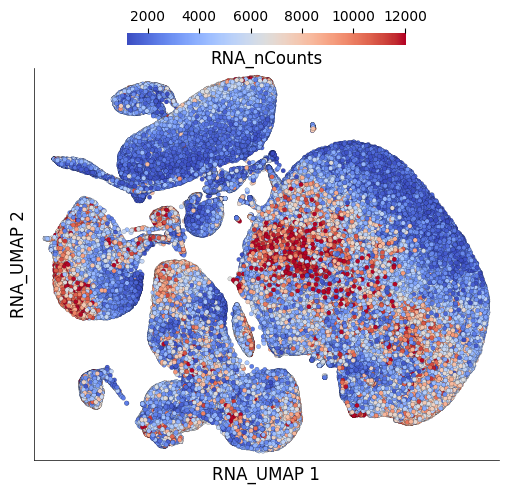

In [32]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm' # visualize data from each column
)

In [ ]:
## You can also use t-distributed Stochastic Neighbor Embedding (TSNE)

In [33]:
ds.run_tsne(
    alpha=10,
    box_h = 1,
    early_iter=250,
    max_iter=500,
    parallel=True
)

##tsne is not available on windows, so run this code elsewhere

ERROR: darwin operating system is currently not supported.


#### 6) Now Cell Clustering

In [62]:
ds.run_leiden_clustering(resolution=1.2) # closer to 0 resolution means less clusters, closer to 1 means more clusters

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


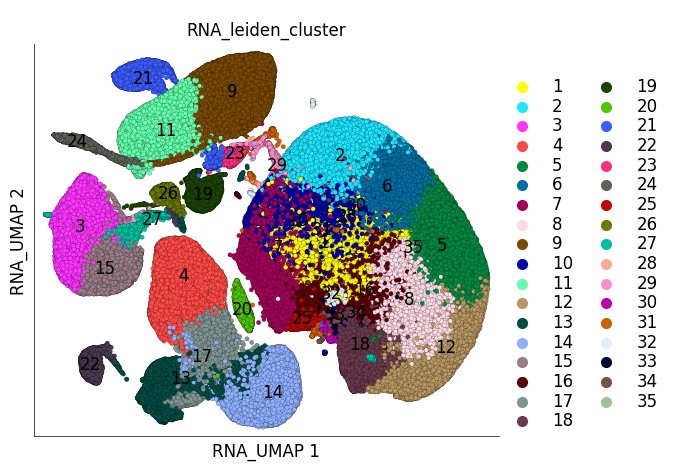

In [63]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [66]:
ds.cells.head() # now we see it works bc we see the success in the RNA_leiden cluster column

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_cluster,RNA_leiden_cluster,RNA_nCounts,RNA_nFeatures,RNA_percentMito,...,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X362_3:TCAGTGAGTATTGACC,10X362_3:TCAGTGAGTATTGACC,11.847340,-2.960084,22,1,11170.0,3082.0,0.402865,...,1.252836,1.936434,-1.956834,0.001513,0.000445,0.828378,False,{98R6UpEqS,11234.0,3100.0
1,True,10X362_5:TCCGTGTGTGAAAGTT,10X362_5:TCCGTGTGTGAAAGTT,16.992125,-8.226686,7,16,6492.0,2287.0,0.400493,...,0.428098,6.749318,17.554855,0.002145,0.000153,0.848476,False,@Emos2s5K+,6527.0,2303.0
2,True,10X362_5:CACGGGTAGAGCAGAA,10X362_5:CACGGGTAGAGCAGAA,21.838242,-1.690997,7,16,6991.0,2712.0,0.386211,...,1.317603,6.266892,17.820768,0.001280,0.000000,0.801024,False,ba|aw+>z=F,7031.0,2733.0
3,False,10X362_5:GATTCTTGTATGTCAC,10X362_5:GATTCTTGTATGTCAC,NaN,NaN,-1,-1,21934.0,4731.0,0.496945,...,-0.648498,24.283781,10.955823,0.001995,0.000000,0.851632,False,r$+8sBgKyG,22060.0,4771.0
4,True,10X362_6:AGGACTTGTATCCTTT,10X362_6:AGGACTTGTATCCTTT,0.867150,15.464523,26,29,12858.0,3214.0,0.303313,...,1.272111,6.356893,17.940919,0.001936,0.000000,0.848084,False,sw*$Gke{CL,12915.0,3241.0


In [67]:
leiden_clusters = ds.cells.to_pandas_dataframe( # output the leiden cluster info into a pds df
    columns=['RNA_leiden_cluster'],
    key='I'
)
leiden_clusters.head()

,RNA_leiden_cluster
0,1
1,16
2,16
4,29
5,12


In [68]:
ds.run_clustering(n_clusters=leiden_clusters.nunique().iloc[0])

INFO: Using existing dendrogram


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


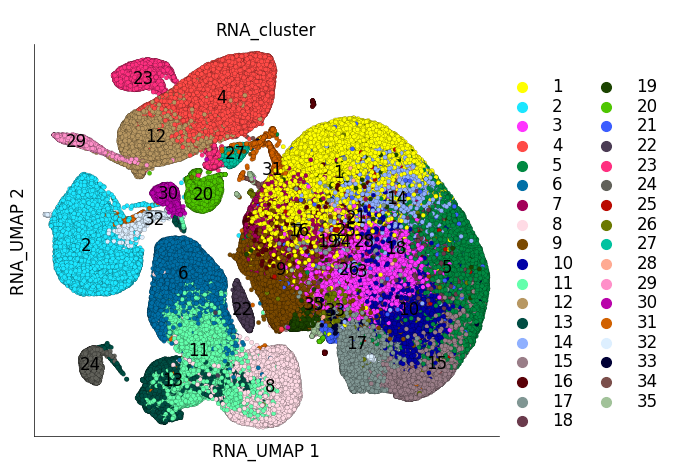

In [70]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster'
)

Constructing graph from dendrogram:   0%|                                                                     …

Identifying the top node for cluster:   0%|                                                                   …

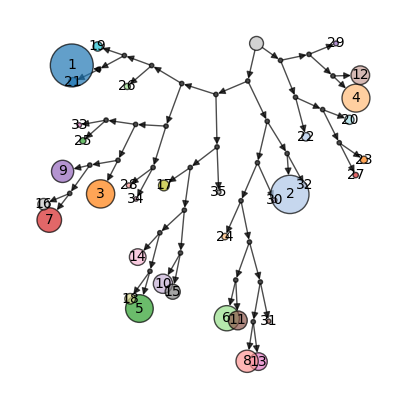

In [71]:
ds.plot_cluster_tree(cluster_key='RNA_cluster', width=1) # this creates the dendograms that only SCARF has built in

#### 7) Identifying Marker Genes

In [72]:
# this is how we can identify the genes that are differentially expressed between the clusters
# Doesn't compute any statistics or anything

ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=100
)

Finding markers:   0%|                                                                                        …

In [ ]:
# now we can plot a heatmap with the top marker genes from each cluster

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


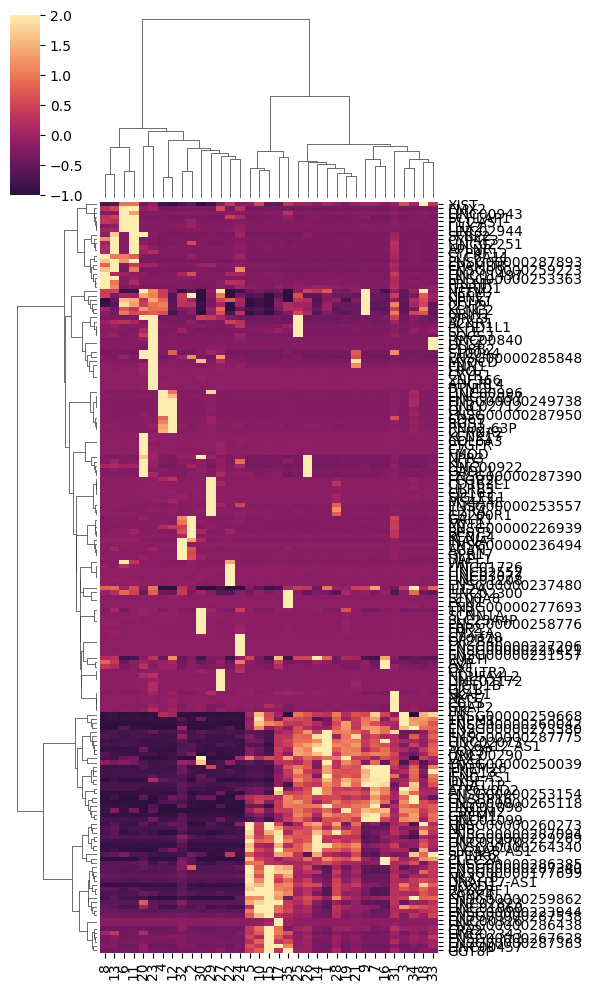

In [73]:
ds.plot_marker_heatmap(
    group_key='RNA_cluster',
    topn=5,
    figsize=(6,10) #, save_dpi=600 (if we wanted a figure)
)

In [74]:
markers = ds.get_markers(
    group_key='RNA_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
markers

# making a df called markers

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,ENSG00000250039,37877.0,0.13424,0.02403,0.00282,0.04124,0.01120,8.52462,0.0
1,1,SLC6A12-AS1,42258.0,0.12738,0.03254,0.00428,0.07364,0.01535,7.60875,0.0
2,1,IL26,3889.0,0.12615,0.00523,0.00055,0.01237,0.00197,9.55064,0.0
3,1,ENSG00000287775,57828.0,0.12242,0.00593,0.00069,0.01174,0.00202,8.62057,0.0
4,1,LINC00290,36794.0,0.10727,0.00866,0.00168,0.01853,0.00583,5.16822,0.0
...,...,...,...,...,...,...,...,...,...,...
37156,1,FYB2,16425.0,0.00023,0.00005,0.00780,0.00018,0.01727,0.00649,0.0
37157,1,SYK,11439.0,0.00023,0.00041,0.09159,0.00127,0.09909,0.00452,0.0
37158,1,ENSG00000287372,57467.0,0.00020,0.00012,0.02682,0.00035,0.05564,0.00462,0.0
37159,1,SRPX2,2655.0,0.00018,0.00006,0.01991,0.00020,0.05301,0.00317,0.0


#### 8) Trinarizer for gene expression & auto-annotation

In [147]:
from scipy.stats import beta as beta_dist
import numpy as np

In [150]:
# define a function for trinarizimg
def trinarize_gene_in_cluster(counts, pseudocount=0.5, low_thresh=0.2, high_thresh=0.5):
    ## definign the prior for pseduo count = 0.5
    # we are making a new array, counts, which is is a 1d array of raw UMI counts for one gene in one cluster
    n = len(counts) # telling us the number of cells in this cluster
    k = np.sum(counts > 0)


    # Creating out posterior with the prior (0.5 counts and)
    alpha_post = k + pseudocount
    beta_post = (n - k) + pseudocount
## basically this portion is the beta(a+k, b+n-k) as in the notebook

    # Now define is gene is off (P(p < low_thresh) = gene is likely off)
    p_off = beta_dist.cdf(low_thresh, alpha_post, beta_post)
    ## Now define if a gene is on (P(p > high_thresh) = gene likely off)
    p_on  = 1 - beta_dist.cdf(high_thresh, alpha_post, beta_post)
    ## Now define is a gene is ambiguous
    p_ambiguous = 1 - p_off - p_on

    scores = {'on': p_on, 'off': p_off, 'ambiguous': p_ambiguous}
    return max(scores, key=scores.get), scores

## Now do a function for building trinarization matrix for scarf
def build_trinarization_matrix(ds, cluster_key='RNA_leiden_cluster'):
    x = ds.cells.fetch_all(cluster_key)
    genes = ds.RNA.feats.fetch_all('names') # We need to use to find the scarf specific things
    clusters = np.unique(x) #ds.cells.fetch_all(cluster_key)#.unique() # use parenthesis to pull things unique
    results = {}
    for cluster in clusters:
        mask = x == cluster # ds.cells.fetch_all(cluster_key) == cluster # use the scarf syntax to fetch the expression 
        cluster_counts = ds.RNA.rawData[mask].compute() # already a sparse matrix so just computing
        results[cluster] = {}
        for i, gene in enumerate(genes):
            gene_counts = cluster_counts[:,i].flatten() # make to a 1d array
            call, _ = trinarize_gene_in_cluster(gene_counts)
            results[cluster][gene] = call
    return results

In [151]:
results = build_trinarization_matrix(ds) # takes a while

In [154]:
results

{-1: {'TSPAN6': 'off',
  'TNMD': 'off',
  'DPM1': 'ambiguous',
  'SCYL3': 'ambiguous',
  'FIRRM': 'off',
  'FGR': 'off',
  'CFH': 'off',
  'FUCA2': 'off',
  'GCLC': 'on',
  'NFYA': 'ambiguous',
  'STPG1': 'ambiguous',
  'NIPAL3': 'on',
  'LAS1L': 'ambiguous',
  'ENPP4': 'on',
  'SEMA3F': 'off',
  'CFTR': 'ambiguous',
  'ANKIB1': 'on',
  'CYP51A1': 'ambiguous',
  'KRIT1': 'off',
  'RAD52': 'ambiguous',
  'BAD': 'off',
  'LAP3': 'ambiguous',
  'CD99': 'off',
  'HS3ST1': 'off',
  'AOC1': 'off',
  'WNT16': 'off',
  'HECW1': 'off',
  'MAD1L1': 'ambiguous',
  'LASP1': 'off',
  'SNX11': 'off',
  'TMEM176A': 'off',
  'M6PR': 'off',
  'KLHL13': 'ambiguous',
  'CYP26B1': 'off',
  'ICA1': 'off',
  'DBNDD1': 'off',
  'ALS2': 'ambiguous',
  'CASP10': 'off',
  'CFLAR': 'on',
  'TFPI': 'off',
  'NDUFAF7': 'ambiguous',
  'RBM5': 'on',
  'MTMR7': 'on',
  'SLC7A2': 'off',
  'ARF5': 'off',
  'SARM1': 'ambiguous',
  'POLDIP2': 'off',
  'PLXND1': 'ambiguous',
  'AK2': 'ambiguous',
  'CD38': 'off',
  'FKBP4

In [164]:
print(list(results.keys()))   # should show -1 through 35, which means ur code worked correctly

[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


#### 9) Actually building the auto-annotater

In [172]:
import os
import yaml
import glob
from pathlib import Path

In [190]:
path = Path('/Users/saatvikviniak/Desktop/Lab work/sc-RNA atlas/auto-annotation/Human_adult/') ## put the path of the folder where the md files are located.

In [206]:
def load_rules(path):
    rules = []
    search_pattern = os.path.join(path, "*.md")
    
    for filename in glob.glob(search_pattern):
        with open (filename) as file:
            doc = next(yaml.load_all(file, Loader=yaml.SafeLoader))
        if doc is None:
            continue
        if "name" in doc:
            name = doc["name"]
        else:
            raise ValueError(os.path.basename(filename) + "this file didn't have a 'name' attribute which is required")
        if "abbreviation" in doc:
            abbreviation = doc["abbreviation"]
        else:
            raise ValueError(os.path.basename(filename) + "this file didn't have a 'abbreviation' attribute which is required")
        if "definition" in doc:
            definition = doc["definition"]
        else:
            raise ValueError(os.path.basename(filename) + "did not contain a 'definition' attribute, which is required.")
        if "categories" in doc:
            categories = doc["categories"]
        else:
            raise ValueError(os.path.basename(filename) + " did not contain a 'categories' attribute, which is required.")
        rules.append({"name": name, "abbreviation": abbreviation, "definition": definition, "categories": categories})
        
    return rules 

In [207]:
rules = load_rules(path)

In [208]:
rules

[{'name': 'Artery endothelial cell',
  'abbreviation': 'ARTERIOLE',
  'definition': '+FLT1 +CLDN5 +PECAM1 +SEMA3G',
  'categories': 'Endomesodermal'},
 {'name': 'D1 medium spiny neuron',
  'abbreviation': 'MSN-D1',
  'definition': '+FOXG1 +SLC32A1 +FOXP1 +FOXP2 +OTOF +DRD1 +RGS9 +GPR88',
  'categories': 'Ectodermal Neuroectodermal Neuronal'},
 {'name': 'Von Economo neuron',
  'abbreviation': 'VonEcon',
  'definition': '+FEZF2 +GABRQ +ITGA4 +BMP3',
  'categories': 'Ectodermal Neuroectodermal Neuronal'},
 {'name': 'Astrocyte',
  'abbreviation': 'ASTRO',
  'definition': '+AQP4 +GJA1 -FOXJ1',
  'categories': 'Ectodermal Neuroectodermal Glial'},
 {'name': 'Microglia (mesoderm)',
  'abbreviation': 'MGL',
  'definition': '+TYROBP +DOCK8 -CD163 -GZMB -FCN1',
  'categories': 'Endomesodermal'},
 {'name': 'choroid plexus (mesoderm)',
  'abbreviation': 'CHRP',
  'definition': '+TTR +CLIC6',
  'categories': 'Endomesodermal'},
 {'name': 'Arachnoid barrier cells',
  'abbreviation': 'ABC',
  'definiti

In [209]:
def parse_definition(definition_str):
    genes = definition_str.strip().split()
    required = [x[1:] for x in genes if x.startswith("+")]
    excluded = [x[1:] for x in genes if x.startswith("-")]
    return required, excluded

In [210]:
def annotate_cluster(present_genes, absent_genes, rules):
    matches = []
    for rule in rules:
        required, excluded = parse_definition(rule['definition'])
        if all(g in present_genes for g in required) and all(g in absent_genes for g in excluded):
            matches.append(rule['abbreviation'])
    return matches

In [211]:
annotations = {}

for cluster, gene_calls in results.items():
    present_genes = {gene for gene, call in gene_calls.items() if call == 'on'}
    absent_genes = {gene for gene, call in gene_calls.items() if call == 'off'}
    annotations[cluster] = annotate_cluster(present_genes, absent_genes, rules)

In [217]:
for cluster, gene_calls in results.items():
    if gene_calls.get('GPR149') == 'on':
        print(f"Cluster {cluster} expresses GPR149 — annotated as: {annotations[cluster]}")

In [219]:
annotations

{-1: ['OLIGO'],
 1: ['OLIGO'],
 2: ['OLIGO'],
 3: ['OPC'],
 4: ['ASTRO'],
 5: ['OLIGO'],
 6: ['OLIGO'],
 7: ['OLIGO'],
 8: ['OLIGO'],
 9: [],
 10: ['OLIGO'],
 11: [],
 12: ['OLIGO'],
 13: ['ASTRO'],
 14: ['ASTRO'],
 15: [],
 16: ['OLIGO'],
 17: ['ASTRO'],
 18: ['OLIGO'],
 19: [],
 20: [],
 21: ['ENDO'],
 22: [],
 23: [],
 24: ['MAC'],
 25: ['OLIGO'],
 26: ['CHRP'],
 27: ['OLIGO', 'COP'],
 28: ['OLIGO'],
 29: ['OLIGO'],
 30: ['OLIGO'],
 31: ['OLIGO'],
 32: ['OLIGO'],
 33: ['OLIGO'],
 34: ['OLIGO'],
 35: ['OLIGO']}

#### 10) Something IG????

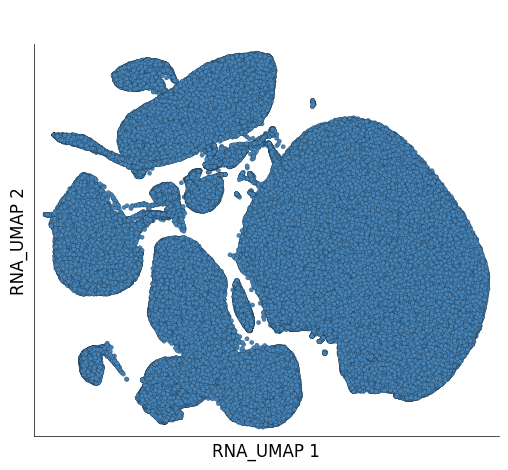

In [223]:
## plot genes of interest in this format of on the UMAP
ds.plot_layout(layout_key='RNA_UMAP', color_by=['GPR149'])

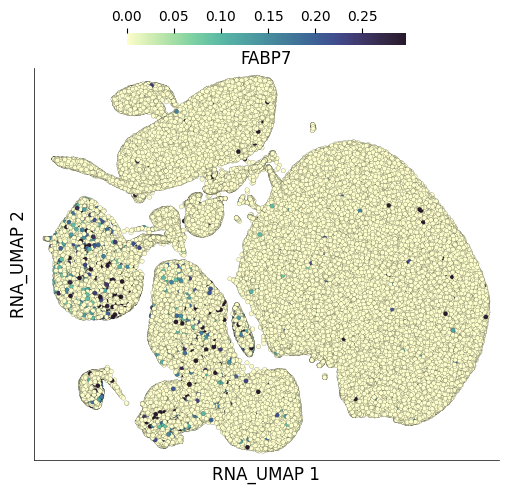

In [203]:
ds.plot_layout(layout_key='RNA_UMAP', color_by='CD14')

In [ ]:
for x in range(0,23): # change 23 to the n+1 clusters you have
    print(f'"{x}":"",')

In [ ]:
cell_type {
    ## paste in the output from for x in range
}

In [ ]:
## Fetch the cluster assignments for non-filtered cells
clusters = ds.cells.fetch('RNA_leiden_cluster', key='I')

# Now Map cluster IDs (as strings) to cell type labels
cell_type_labels = [cell_type[str(c)] for c in clusters]

## now insert the cells
ds.cells.insert(
    column_name='cell_type',
    values=cell_type_labels,
    key='I',          # only insert for non-filtered cells
    overwrite=True    # set True if re-running)


In [ ]:
ds.plot_layout(layout_key='RNA_UMAP', color_by='cell_type')


In [224]:
markers[markers['feature_name'] == 'GPR149']

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
20100,1,GPR149,13702.0,0.02724,0.00098,0.00097,0.00263,0.00385,1.01058,1.865395e-10
